# Staged upper-agent curriculum: scenario plots

This notebook reads the **active** scenarios from `upper_agent_training_scenarios.py`. It visualizes the fixed, slow, and fast tiers using the same 3-gNB geometry and UE placement equation as the training environment.

Run all cells after changing the curriculum; the plots update automatically.

## 1. Imports and active configuration

This cell locates the repository, imports the real scenario catalog, and defines common colors. No scenario is copied into the notebook.

In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
from IPython.display import display

from global_ppo_3gnb_env import DEFAULT_GNB_CONFIGS_3
from upper_agent_training_scenarios import (
    UPPER_TRAINING_SCENARIOS,
    UPPER_TRAINING_SCENARIO_BY_NAME,
)

plt.style.use('seaborn-v0_8-whitegrid')
GNBS = {int(g['id']): g for g in DEFAULT_GNB_CONFIGS_3}
SLICE_COLORS = {'eMBB': '#2878B5', 'URLLC': '#D9534F', 'mMTC': '#3A923A'}
TIER_COLORS = {'fixed': '#6A5ACD', 'slow': '#E69F00', 'fast': '#CC3311'}

print(f'Repository: {ROOT}')
print(f'Active scenarios: {len(UPPER_TRAINING_SCENARIOS)}')

Repository: /home/oussama/Desktop/chech
Active scenarios: 25


## 2. Curriculum summary

Each row represents one episode type. `total_ues` is the number of UEs created, while `offered_load` is the sum of the configured group loads. The bar plots verify tier balance and physical episode duration.

,scenario,tier,duration_s,groups,total_ues,offered_load,slices
0,fixed_embb_g0_overlap,fixed,16.0,1,10,0.86,eMBB
1,fixed_urllc_g1_overlap,fixed,16.0,1,10,0.84,URLLC
2,fixed_mmtc_g2_overlap,fixed,16.0,1,12,0.84,mMTC
3,fixed_dual_slice_g1,fixed,18.0,2,20,1.64,"URLLC, eMBB"
4,fixed_competing_sources_g1,fixed,18.0,2,20,1.66,"URLLC, eMBB"
5,fixed_preloaded_target,fixed,18.0,2,18,1.46,eMBB
6,embb_g0_to_g1_slow,slow,20.0,1,10,0.90,eMBB
7,urllc_g1_to_g2_slow,slow,20.0,1,10,0.88,URLLC
8,mmtc_g2_to_g0_slow,slow,20.0,1,12,0.84,mMTC
9,mixed_g0_release,slow,24.0,3,32,2.25,"URLLC, eMBB, mMTC"


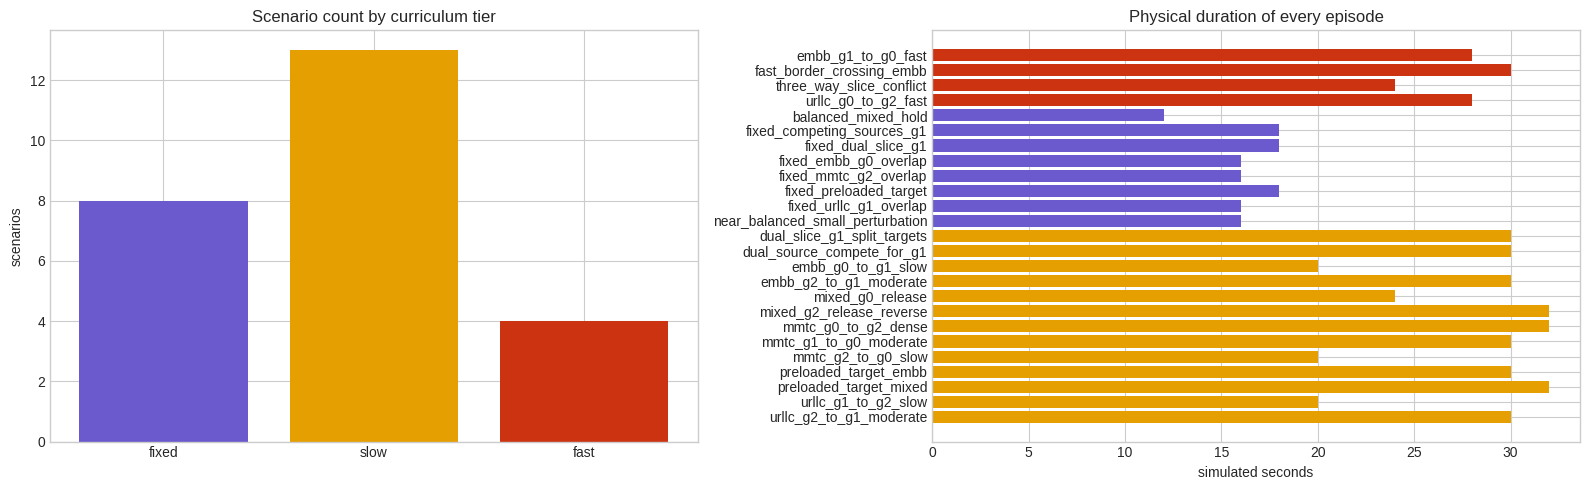

In [2]:
summary_rows = []
for scenario in UPPER_TRAINING_SCENARIOS:
    summary_rows.append({
        'scenario': scenario.name,
        'tier': scenario.tier,
        'duration_s': scenario.duration_s,
        'groups': len(scenario.groups),
        'total_ues': sum(g.count for g in scenario.groups),
        'offered_load': sum(g.total_load for g in scenario.groups),
        'slices': ', '.join(sorted({g.slice_type for g in scenario.groups})),
    })
summary = pd.DataFrame(summary_rows)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
tier_order = ['fixed', 'slow', 'fast']
tier_counts = summary.tier.value_counts().reindex(tier_order, fill_value=0)
axes[0].bar(tier_counts.index, tier_counts.values,
            color=[TIER_COLORS[x] for x in tier_counts.index])
axes[0].set(title='Scenario count by curriculum tier', ylabel='scenarios')

ordered = summary.sort_values(['tier', 'scenario'])
axes[1].barh(ordered.scenario, ordered.duration_s,
             color=ordered.tier.map(TIER_COLORS))
axes[1].set(title='Physical duration of every episode', xlabel='simulated seconds')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Geometry helpers

These functions reproduce `_training_group_ue_state()` from `global_ppo_3gnb_env.py`:

- A group without a target is arranged in a small ring around its source gNB.
- A targeted group starts partway along the source-to-target link, with a lateral offset and 5 m spacing between UEs.
- Its end position is `start + velocity × scenario duration`.
- Fixed targeted groups remain in the overlap region because their speed is zero.

In [3]:
def ue_start_state(group, ue_idx, group_idx):
    source = GNBS[group.source_gnb]
    if group.target_gnb is None:
        angle = 2 * np.pi * (ue_idx + 1) / max(group.count, 1)
        radius = 35.0 + 8.0 * group_idx
        return np.array([source['x'] + radius*np.cos(angle),
                         source['y'] + radius*np.sin(angle)]), np.zeros(2)

    target = GNBS[group.target_gnb]
    delta = np.array([target['x'] - source['x'], target['y'] - source['y']], dtype=float)
    unit = delta / max(np.linalg.norm(delta), 1e-9)
    perpendicular = np.array([-unit[1], unit[0]])
    lateral = group.lateral_offset_m + (ue_idx - 0.5*(group.count - 1))*5.0
    start = np.array([source['x'], source['y']]) + group.path_progress*delta + lateral*perpendicular
    velocity = group.speed_mps * unit
    return start, velocity

def scenario_points(scenario):
    rows = []
    for group_idx, group in enumerate(scenario.groups):
        for ue_idx in range(group.count):
            start, velocity = ue_start_state(group, ue_idx, group_idx)
            end = start + velocity * scenario.duration_s
            rows.append({
                'slice': group.slice_type, 'source': group.source_gnb,
                'target': group.target_gnb, 'speed_mps': group.speed_mps,
                'x0': start[0], 'y0': start[1], 'x1': end[0], 'y1': end[1],
            })
    return pd.DataFrame(rows)

def draw_network(ax):
    for g in GNBS.values():
        ax.add_patch(Circle((g['x'], g['y']), g['coverage_radius'],
                            fill=False, color='gray', alpha=0.20, lw=1.1))
        ax.scatter(g['x'], g['y'], marker='^', s=120, color='black', zorder=6)
        ax.text(g['x'] + 10, g['y'] + 10, f"g{g['id']}", weight='bold')

def plot_scenario(ax, scenario, show_labels=False):
    draw_network(ax)
    points = scenario_points(scenario)
    for slice_type, part in points.groupby('slice'):
        color = SLICE_COLORS[slice_type]
        moving = part.speed_mps.gt(0)
        ax.scatter(part.x0, part.y0, s=24, color=color, alpha=0.85, zorder=4)
        ax.scatter(part.loc[moving, 'x1'], part.loc[moving, 'y1'], s=22,
                   marker='x', color=color, zorder=4)
        for row in part[moving].itertuples():
            ax.annotate('', xy=(row.x1, row.y1), xytext=(row.x0, row.y0),
                        arrowprops=dict(arrowstyle='->', color=color, alpha=0.32, lw=0.8))
    if show_labels:
        for i, group in enumerate(scenario.groups):
            start, _ = ue_start_state(group, (group.count - 1)//2, i)
            target = '-' if group.target_gnb is None else f'g{group.target_gnb}'
            ax.text(start[0], start[1] - 28,
                    f'{group.slice_type}: n={group.count}, g{group.source_gnb}→{target}\n'
                    f'load={group.total_load:.2f}, v={group.speed_mps:g} m/s',
                    fontsize=8, ha='center', va='top', color=SLICE_COLORS[group.slice_type])
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-290, 740)
    ax.set_ylim(-290, 760)
    ax.set_title(f'{scenario.name}\n{scenario.tier} | {scenario.duration_s:g} s',
                 color=TIER_COLORS[scenario.tier], fontsize=10)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')

## 4. Plot the complete scenario catalog

A filled dot is a UE start position, an `×` is its episode-end position, and an arrow is its path. Coverage circles show whether the route remains inside the three-gNB region.

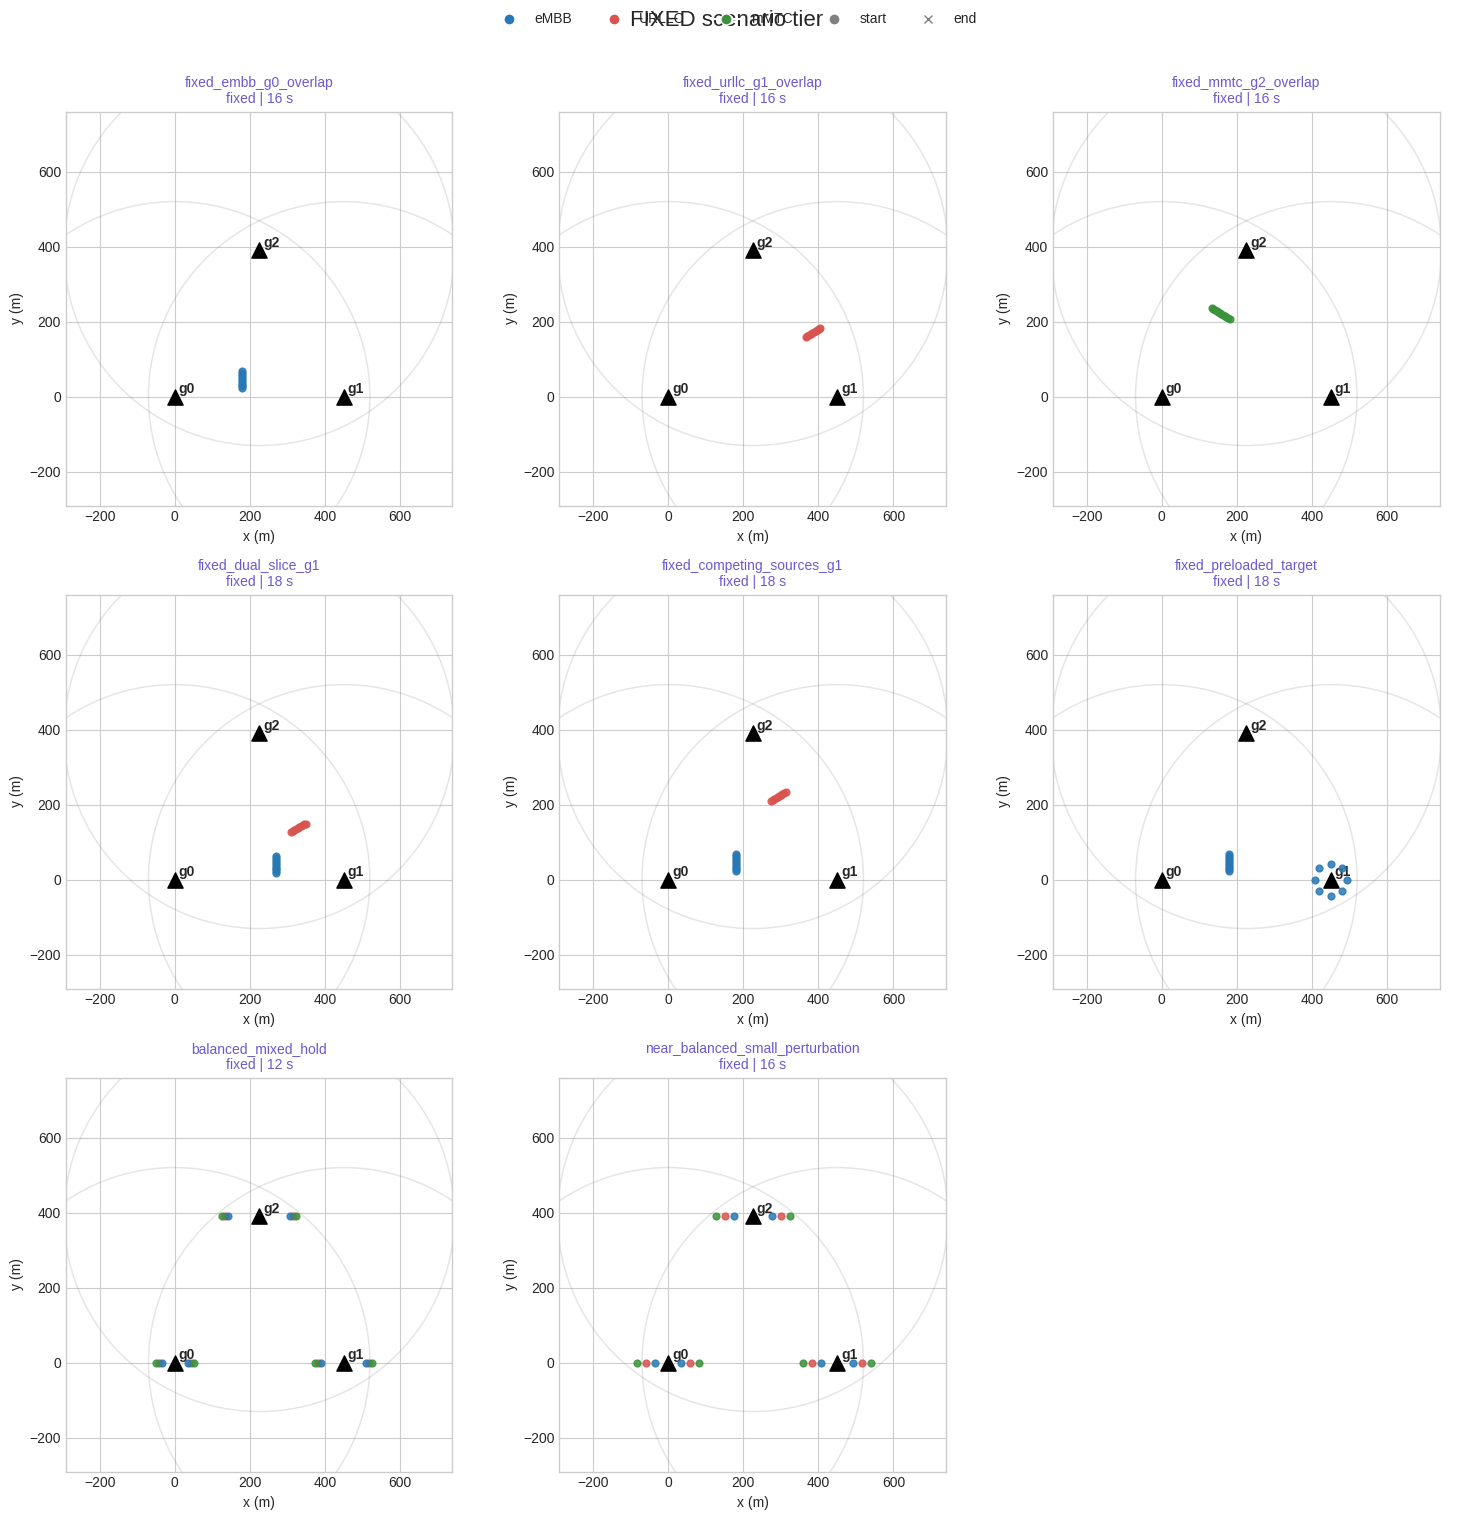

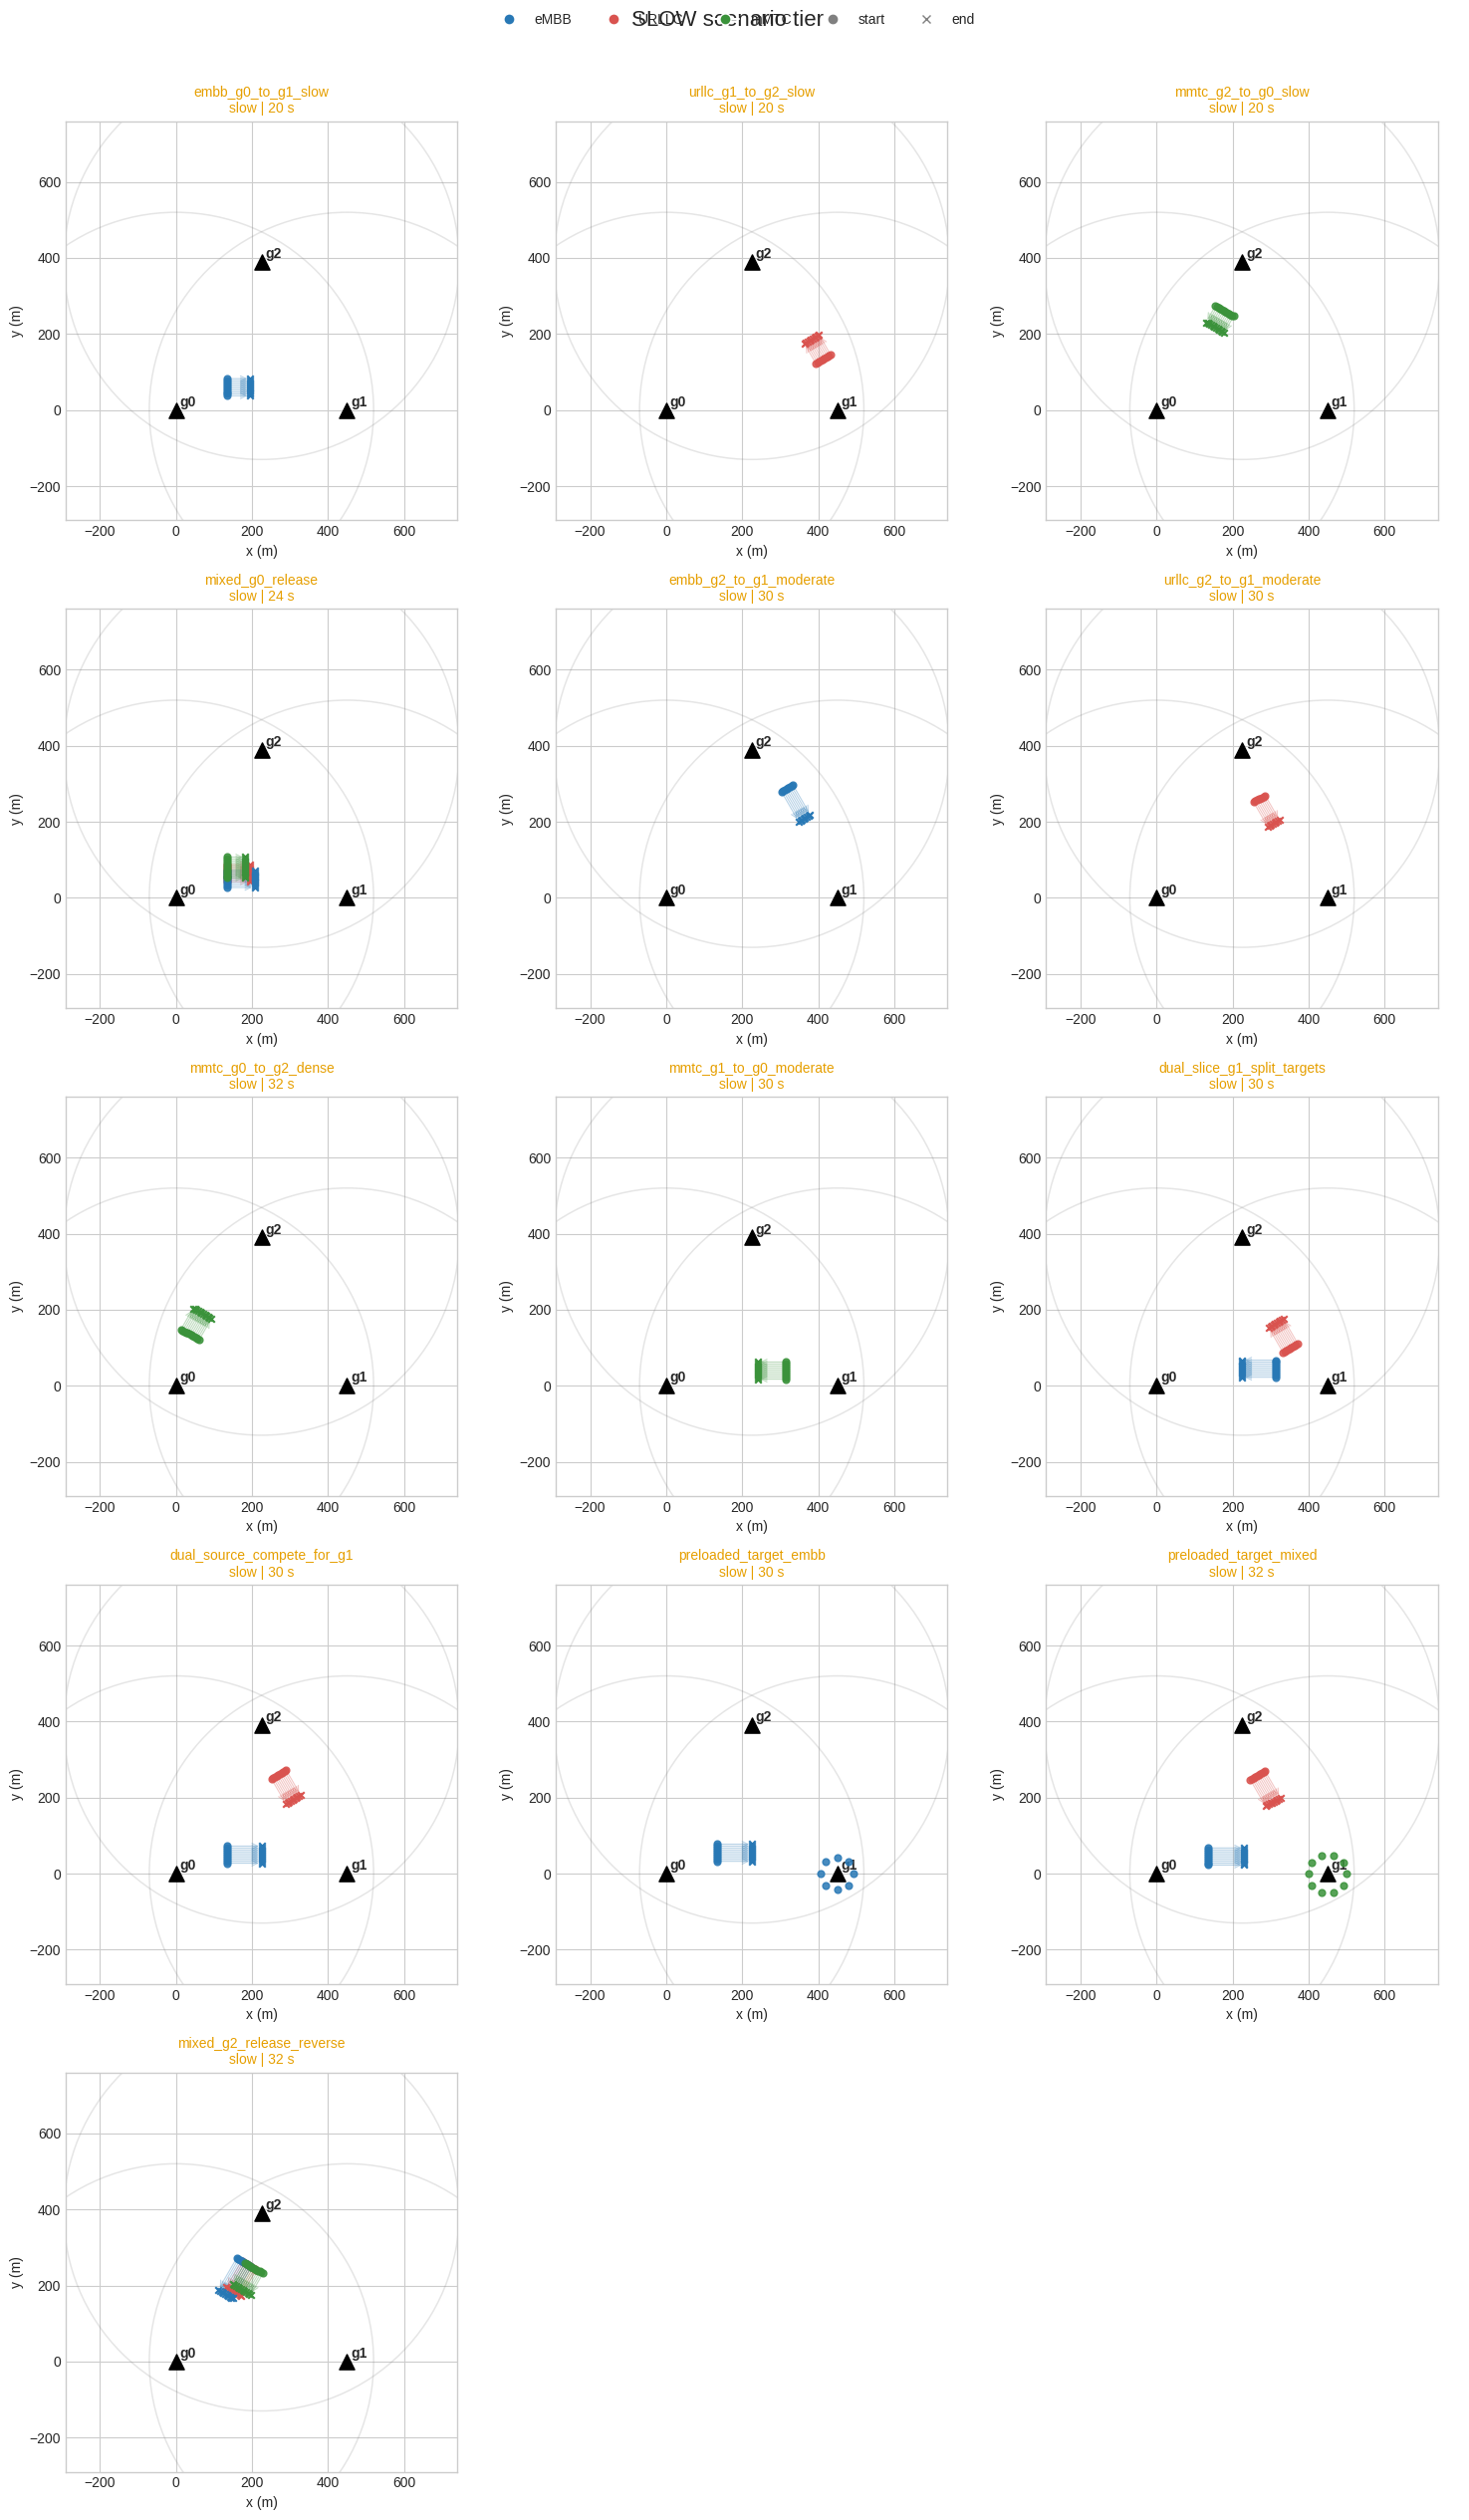

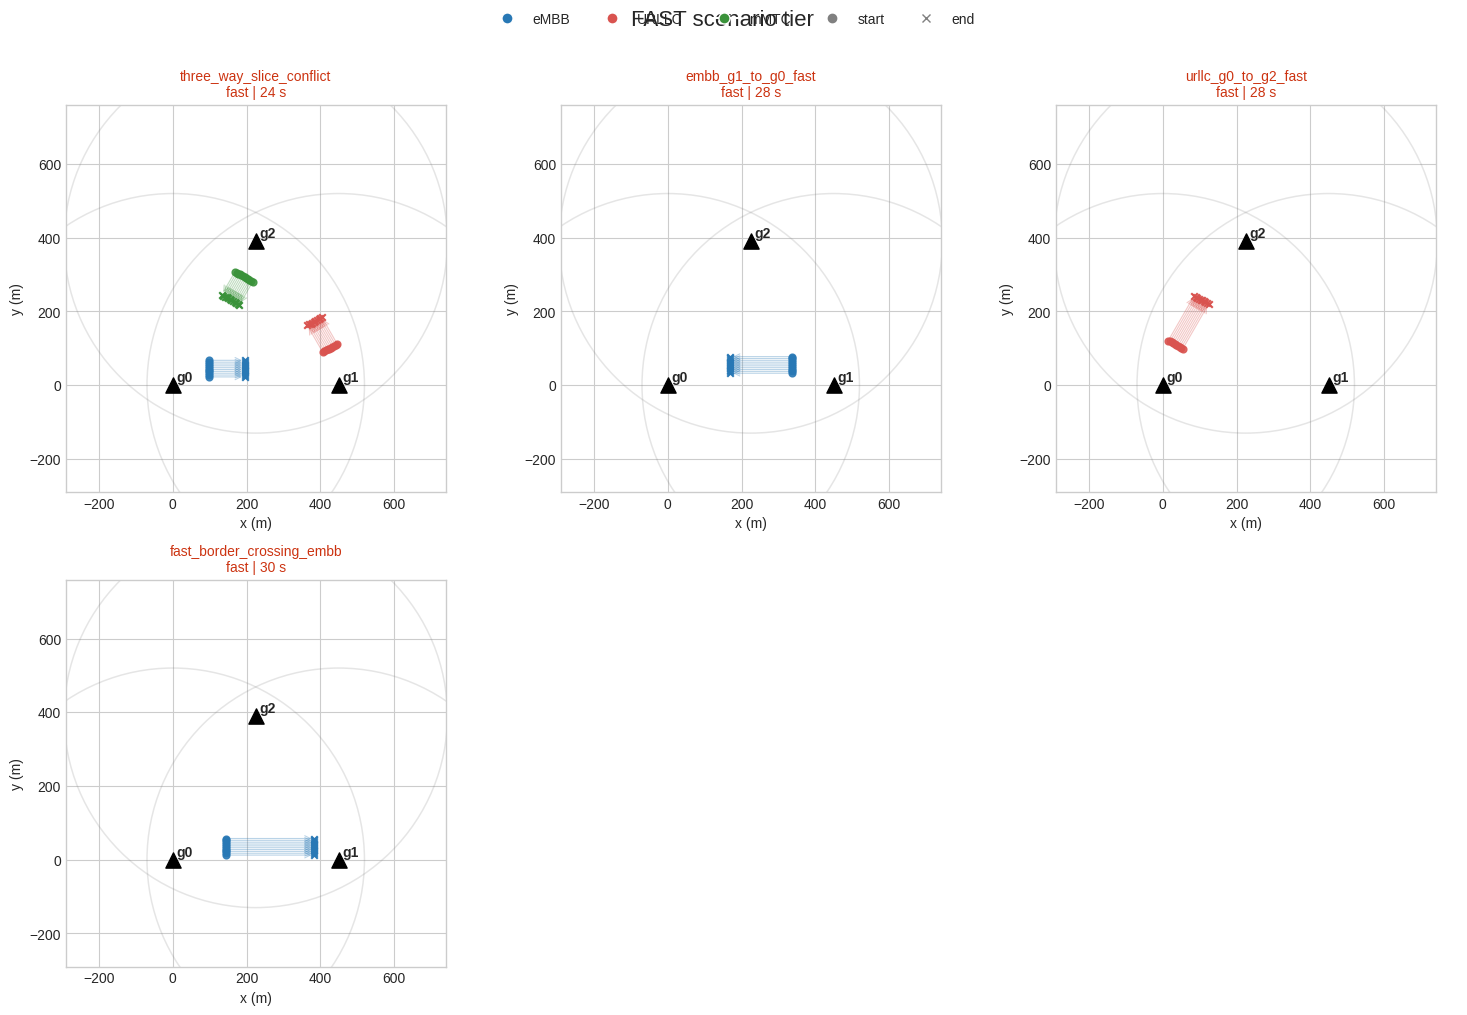

In [4]:
for tier in ['fixed', 'slow', 'fast']:
    scenarios = [s for s in UPPER_TRAINING_SCENARIOS if s.tier == tier]
    ncols = 3
    nrows = int(np.ceil(len(scenarios) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows), squeeze=False)
    for ax, scenario in zip(axes.flat, scenarios):
        plot_scenario(ax, scenario)
    for ax in axes.flat[len(scenarios):]:
        ax.axis('off')
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=c, label=s, markersize=8)
        for s, c in SLICE_COLORS.items()
    ] + [
        Line2D([0], [0], marker='o', color='gray', lw=0, label='start'),
        Line2D([0], [0], marker='x', color='gray', lw=0, label='end'),
    ]
    fig.legend(handles=handles, loc='upper center', ncol=5)
    fig.suptitle(f'{tier.upper()} scenario tier', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

## 5. Inspect one scenario in detail

Change `SCENARIO_NAME` to inspect any catalog entry. The left plot includes group annotations. The right plot is the configured initial load matrix: rows are gNBs and columns are slices.

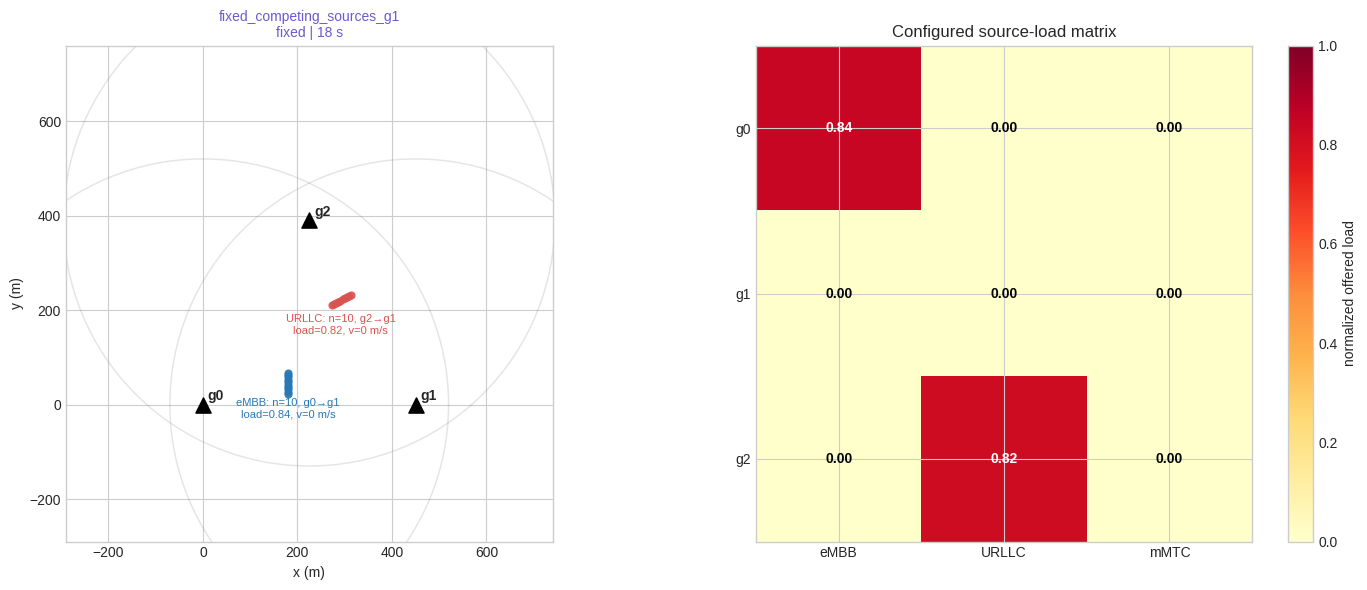

,slice,source,target,UEs,total_load,speed_mps,path_progress,lateral_offset_m
0,eMBB,g0,g1,10,0.84,0.0,0.4,45.0
1,URLLC,g2,g1,10,0.82,0.0,0.4,-25.0


Two fixed overloaded sources compete for safe admission at gNB1.


In [5]:
SCENARIO_NAME = 'fixed_competing_sources_g1'
scenario = UPPER_TRAINING_SCENARIO_BY_NAME[SCENARIO_NAME]

slice_order = ['eMBB', 'URLLC', 'mMTC']
load_matrix = np.zeros((3, 3))
for group in scenario.groups:
    load_matrix[group.source_gnb, slice_order.index(group.slice_type)] += group.total_load

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_scenario(axes[0], scenario, show_labels=True)
image = axes[1].imshow(load_matrix, cmap='YlOrRd', vmin=0, vmax=max(1.0, load_matrix.max()))
axes[1].set_xticks(range(3), slice_order)
axes[1].set_yticks(range(3), ['g0', 'g1', 'g2'])
axes[1].set_title('Configured source-load matrix')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{load_matrix[i, j]:.2f}', ha='center', va='center',
                     color='white' if load_matrix[i, j] > 0.55 else 'black', weight='bold')
fig.colorbar(image, ax=axes[1], label='normalized offered load')
plt.tight_layout()
plt.show()

display(pd.DataFrame([{
    'slice': g.slice_type, 'source': f'g{g.source_gnb}',
    'target': '-' if g.target_gnb is None else f'g{g.target_gnb}',
    'UEs': g.count, 'total_load': g.total_load,
    'speed_mps': g.speed_mps, 'path_progress': g.path_progress,
    'lateral_offset_m': g.lateral_offset_m,
} for g in scenario.groups]))
print(scenario.description)

## 6. Staged training schedule

With the default CLI values, episodes 1–500 draw only from fixed scenarios. Episodes 501–1500 draw from fixed and slow scenarios. Later episodes use the full weighted mix: approximately 40% fixed, 40% slow, and 20% fast.

,stage,episode_start,episode_end,fixed_share,slow_share,fast_share
0,1: learn controllability,1,500,1.000000,0.000000,0.0
1,2: add slow mobility,501,1500,0.380952,0.619048,0.0
2,3: full robustness,1501,2500,0.400000,0.400000,0.2


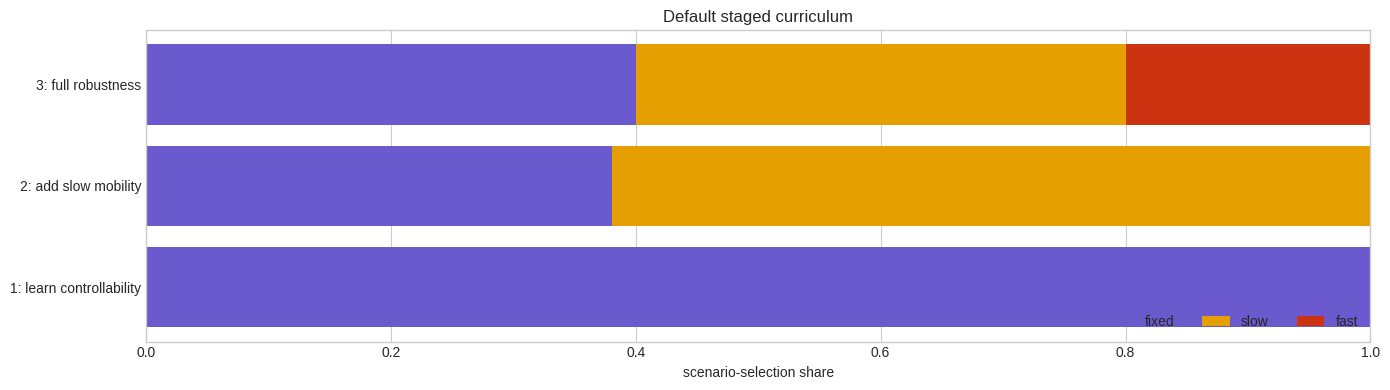

In [6]:
stage_data = pd.DataFrame({
    'stage': ['1: learn controllability', '2: add slow mobility', '3: full robustness'],
    'episode_start': [1, 501, 1501],
    'episode_end': [500, 1500, 2500],
    'fixed_share': [1.0, 8/21, 0.4],
    'slow_share': [0.0, 13/21, 0.4],
    'fast_share': [0.0, 0.0, 0.2],
})
display(stage_data)

fig, ax = plt.subplots(figsize=(14, 4))
bottom = np.zeros(len(stage_data))
for tier in ['fixed', 'slow', 'fast']:
    values = stage_data[f'{tier}_share'].to_numpy()
    ax.barh(stage_data.stage, values, left=bottom, color=TIER_COLORS[tier], label=tier)
    bottom += values
ax.set(xlim=(0, 1), xlabel='scenario-selection share', title='Default staged curriculum')
ax.legend(ncol=3, loc='lower right')
plt.tight_layout()
plt.show()